# Retail Bank Customer Churn — Exploratory Analysis

A retail bank operating across France, Spain and Germany wants to understand why
customers leave. This notebook is the exploratory analysis behind the project:
data quality, where churn concentrates, and which cohorts the bank should
prioritise for retention.

The reproducible pipeline lives in `src/` and `sql/`; this notebook is the
exploration that motivated those queries.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 25)

raw = pd.read_csv("../data/raw/Churn_Modelling.csv")
print(raw.shape)
raw.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1. Structure and data quality

Unusually for a real extract, this one is pristine — the value here is in framing
and feature engineering, not cleaning.

In [2]:
print("Duplicate customers:", int(raw["CustomerId"].duplicated().sum()))
print("Missing values:", int(raw.isna().sum().sum()))

# RowNumber / CustomerId / Surname are pure identifiers -> drop for analysis.
df = raw.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()
df["churned"] = df["Exited"].astype(int)

overall = df["churned"].mean() * 100
print(f"{len(df):,} customers | overall churn: {overall:.1f}%")

Duplicate customers: 0
Missing values: 0
10,000 customers | overall churn: 20.4%


A 20.4% churn rate means roughly 1 in 5 customers has left — high enough that
small targeting improvements move real revenue. The rest of the analysis asks:
*which* 1 in 5?

## 2. Geography — where churn concentrates

The bank operates in three countries. Are they equally sticky?

In [3]:
geo = (
    df.groupby("Geography")["churned"]
    .agg(customers="size", churn_rate="mean")
    .assign(churn_rate=lambda x: (x["churn_rate"] * 100).round(1))
    .sort_values("churn_rate", ascending=False)
)
geo

,customers,churn_rate
Geography,,
Germany,2509,32.4
Spain,2477,16.7
France,5014,16.2


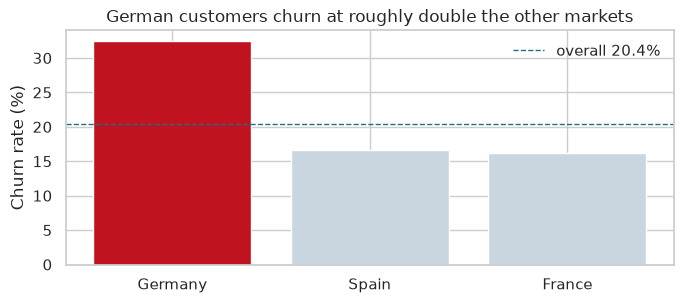

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
colors = ["#c1121f" if g == "Germany" else "#c9d6df" for g in geo.index]
ax.bar(geo.index, geo["churn_rate"], color=colors)
ax.axhline(overall, color="#1f6f8b", ls="--", lw=1, label=f"overall {overall:.1f}%")
ax.set_ylabel("Churn rate (%)")
ax.set_title("German customers churn at roughly double the other markets")
ax.legend(frameon=False)
plt.tight_layout()

**Germany churns at 32.4%** — about double France (16.2%) and Spain (16.7%),
despite Germany being only a quarter of the book. A striking detail: German
customers carry far higher balances (avg ~120k vs ~62k elsewhere), so the bank is
losing its *most valuable* customers fastest. That makes Germany the clear
priority cohort.

## 3. Activity and product holdings — the actionable levers

Two fields the bank can actually influence: whether a customer is an active
member, and how many products they hold.

In [5]:
activity = (
    df.groupby("IsActiveMember")["churned"]
    .agg(customers="size", churn_rate="mean")
    .assign(churn_rate=lambda x: (x["churn_rate"] * 100).round(1))
    .rename(index={0: "inactive", 1: "active"})
)
activity

,customers,churn_rate
IsActiveMember,,
inactive,4849,26.9
active,5151,14.3


In [6]:
prod = (
    df.groupby("NumOfProducts")["churned"]
    .agg(customers="size", churn_rate="mean")
    .assign(churn_rate=lambda x: (x["churn_rate"] * 100).round(1))
)
prod

,customers,churn_rate
NumOfProducts,,
1,5084,27.7
2,4590,7.6
3,266,82.7
4,60,100.0


**Inactive members churn at 26.9% vs 14.3% for active ones** — nearly double.
Re-activation is one of the highest-leverage, most controllable interventions
available.

Products tell a sharper story. Churn is **U-shaped and extreme**:
- 1 product → 27.7%
- 2 products → 7.6% (the sweet spot)
- 3 products → 82.7%
- 4 products → 100%

The 3–4 product cohorts are tiny (≈300 and ≈60 customers) so the rates are
noisy, **but** a near-total churn among the most heavily-sold customers is a red
flag worth a deeper operational look — likely a mis-sold or unhappy segment, not
a loyalty signal. The clean takeaway: moving single-product customers to a second
product is associated with the lowest churn band.

## 4. Demographics — age is the strongest demographic driver

Age is not linear with churn — worth plotting rather than assuming.

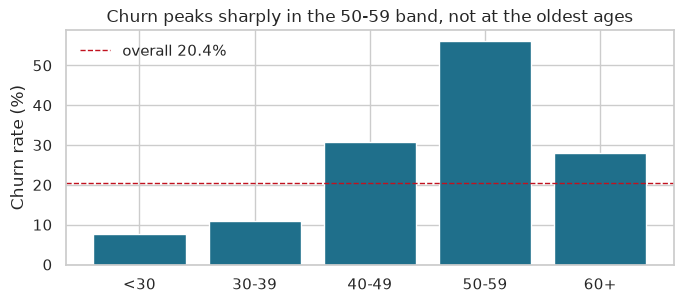

In [7]:
age_band = pd.cut(
    df["Age"], bins=[0, 30, 40, 50, 60, 200],
    labels=["<30", "30-39", "40-49", "50-59", "60+"], right=False,
)
by_age = (
    df.groupby(age_band, observed=True)["churned"]
    .agg(customers="size", churn_rate="mean")
    .assign(churn_rate=lambda x: (x["churn_rate"] * 100).round(1))
)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(by_age.index.astype(str), by_age["churn_rate"], color="#1f6f8b")
ax.axhline(overall, color="#c1121f", ls="--", lw=1, label=f"overall {overall:.1f}%")
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn peaks sharply in the 50-59 band, not at the oldest ages")
ax.legend(frameon=False)
plt.tight_layout()

Churn **peaks at 56% in the 50-59 band** and then *falls* for the 60+ group —
a mid-life peak, not a steady rise. Combined with gender (women churn 25.1% vs
men 16.5%), the highest-risk demographic profile is a **middle-aged woman in
Germany**, which the geography cut already hinted at (German women churn 37.6%).

## 5. Balance — a counter-intuitive result

In [8]:
balance_band = df["Balance"].map(
    lambda b: "zero" if b == 0
    else "under_100k" if b < 100_000
    else "100k-150k" if b < 150_000
    else "over_150k"
)
(
    df.groupby(balance_band)["churned"]
    .agg(customers="size", churn_rate="mean")
    .assign(churn_rate=lambda x: (x["churn_rate"] * 100).round(1))
    .reindex(["zero", "under_100k", "100k-150k", "over_150k"])
)

,customers,churn_rate
Balance,,
zero,3617,13.8
under_100k,1584,20.6
100k-150k,3830,25.8
over_150k,969,23.1


Naively you'd expect empty accounts to be flight risks, but **zero-balance
customers churn the *least* (13.8%)** while funded customers churn more (20–26%).
The reason ties back to geography: zero-balance customers are concentrated in
France/Spain (the sticky markets), while Germany's high-balance customers drive
both the high balances *and* the high churn. It's a reminder to check whether a
relationship is real or a proxy for another variable — here, balance is partly a
stand-in for country.

## 6. Takeaways

| # | Finding | Retention action |
|---|---------|------------------|
| 1 | Germany churns at 32% with the highest balances | Make Germany the priority cohort — its losses are the most valuable |
| 2 | Inactive members churn ~2x active ones (27% vs 14%) | Re-activation campaigns — the most controllable lever |
| 3 | Single-product customers churn 28% vs 8% at two | Cross-sell single-product customers to a second product |
| 4 | Churn peaks at 56% for ages 50-59, women > men | Target middle-aged customers, especially women in Germany |

The polished versions of these cuts live in `sql/` (queries),
`outputs/tables/` (results) and `tableau/` (dashboard extracts).